In [32]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

import dill as dill

# probes_forecast = ['ky','kk', 'gg', 'gy', 'gk' ,'ge']
# sc_val = 500

import ast
print(sys.argv)
# probes_forecast = list(sys.argv[1])
# probes_forecast = sys.argv[1].split(',')
probes_forecast = ['kk', 'gg', 'gk']
# sc_val = int(sys.argv[2])

sc_val = 500

print(probes_forecast, sc_val)

from scipy.interpolate import interp1d
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

df_nz_comoving = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_comoving_density.txt')
    
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]

# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_colossus = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665}
cosmo_params_dict = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
# sim_params_dict['gamma_rhogas'] = 2.0
# sim_params_dict['delta_rhogas'] = 7.0

sim_params_dict['gamma_rhogas'] = 1.2
sim_params_dict['delta_rhogas'] = 6.0


sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 3.0
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = -0.025
sim_params_dict['nu_theta_ej_z'] = 0.025

sim_params_dict['log10_Mc0'] = 14.38
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 0.6
sim_params_dict['nu_z'] = 0.0
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

# hod_params_dict = {}
# hod_params_dict['logMmin'] = 12.88
# hod_params_dict['sigma_logM'] = 0.2
# hod_params_dict['logM0'] = 12.88
# hod_params_dict['logM1'] = 14.0
# hod_params_dict['alpha'] = 1.3
# sim_params_dict['hod_params'] = hod_params_dict
# sim_params_dict['hod_type'] = 'Zheng05'

sim_params_dict['log10M1_fshmr'] = 12.35
sim_params_dict['log10Mstar0_fshmr'] = 10.72
sim_params_dict['beta_fshmr'] = 0.44
sim_params_dict['delta_fshmr'] = 0.57
sim_params_dict['gamma_fshmr'] = 1.56
sim_params_dict['Bcut_Nsat'] = 1.69
sim_params_dict['Bsat_Nsat'] = 9.01
sim_params_dict['betacut_Nsat'] = 0.6
sim_params_dict['betasat_Nsat'] = 0.74
sim_params_dict['alphasat_Nsat'] = 1.0
sim_params_dict['siglogMstar_Ncen'] = 0.25

sim_params_dict['nbar_gal_comoving_zarray'] = zarray_comoving
sim_params_dict['nbar_gal_comoving_val'] = nz_comoving

halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 8, 32
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 2.0, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.5
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.4
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = True
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)


h = cosmo_params_dict['H0']/100
ks = np.geomspace(5e-2,50,15) # wavenumbers
ks_wh = ks / h
analysis_dict['k_array_survey'] = jnp.array(ks_wh)
# analysis_dict['k_array_survey'] = jnp.array(ks_wh)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]/np.sqrt(2)
# analysis_dict['neff_arcmin2_SN_bins'] = [2.24,2.24,2.24,2.24,2.24] * 2
analysis_dict['neff_arcmin2_SN_bins'] = [4.64, 4.64, 4.64, 4.64, 4.64]


Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
# analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
print(analysis_dict['nbar_lens_bins'])
other_params_dict = {}
other_params_dict['A_IA'] = 0.5
other_params_dict['eta_IA'] = 0.1
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])






import pickle as pk

# df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod.pk', 'rb'))
df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk', 'rb'))
probes_all = df['probes']
ell_edges_left = df['edges_left']
ell_edges_right = df['edges_right']
ell_array = df['ell_array']
k_array = df['k_array']
cov_total = df['cov_mat']
Cl_total = df['Cl_Pk']
bin_comb_all_wprobe = df['bin_comb_all_wprobe']



import copy
from tqdm import tqdm
from get_power_spectra import get_power_BCMP
get_power_BCMP_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((cov_total.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
    if probe1 == 'kk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gg':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gy':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

edge_left_pge = ell_edges_left[-1]
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])
Cl_all_fid = copy.deepcopy(Cl_all)


import copy
from tqdm import tqdm
from get_power_spectra import get_power_BCMP
analysis_dict_vary = copy.deepcopy(analysis_dict)
analysis_dict_vary['calc_nfw_only'] = True
get_power_BCMP_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict_vary, other_params_dict, verbose_time=False)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((cov_total.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
    if probe1 == 'kk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gg':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gy':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

edge_left_pge = ell_edges_left[-1]
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])
Cl_all_nfw = copy.deepcopy(Cl_all)

Delta_Cl_all = Cl_all_nfw - Cl_all_fid

print(Delta_Cl_all)

ell_min_max_dict = {'ky':[0, 11000], 'kk':[0, 11000], 'gg':[0, 11000], 'gk':[0, 11000], 'ge':[0, 11000]}
# probes_forecast = ['ky','kk', 'gg', 'gy', 'gk' ,'ge']
# sc_val = 500

probes_forecast_all_str = '_'.join(probes_forecast)

# probes_forecast = ['kk', 'gk' ,'ge']
# probes_forecast = ['gg' ,'kk', 'gk','ge']
# probes_forecast = ['gg', 'gk', 'kk' ,'ge']
# probes_forecast = ['gg', 'gk', 'kk' ]
# probes_forecast = ['kk', 'gk' ]
# probes_forecast = ['gg']
# probes_forecast = ['ky','kk', 'gy', 'gk' ]
ell_sel_min = []
ell_sel_max = []
for jp in range(len(probes_forecast)):
    indp = probes_all.index(probes_forecast[jp])
    # print(indp)
    ell_sel_min.append(ell_edges_left[indp])
    ell_sel_max.append(ell_edges_right[indp])
    print(probes_forecast[jp], ell_sel_min[jp], ell_sel_max[jp])

ell_sel_min = np.array(ell_sel_min)
ell_sel_max = np.array(ell_sel_max)
argsort_min = np.argsort(ell_sel_min)
probes_forecast = [probes_forecast[jp] for jp in argsort_min]
ell_sel_min = ell_sel_min[argsort_min]
ell_sel_max = ell_sel_max[argsort_min]


import yaml

fname = abs_path_data + f'/pge/scale_cuts_all_probes_ellmax_{sc_val}.yaml'
with open(fname, 'r') as stream:
	sc_all = yaml.load(stream, Loader=yaml.SafeLoader)

# scval_new = 500
# sc_new = {}
# for key1 in sc_all.keys():
#     sc_new[key1] = {}
#     if key1 != 'ge':
#         for key2 in sc_all[key1].keys():
#             sc_new[key1][key2] = list([0, scval_new])
#     else:
#         sc_new[key1] = sc_all[key1]

# fname_new = abs_path_data + f'/pge/scale_cuts_all_probes_ellmax_{scval_new}.yaml'
# with open(fname_new, 'w') as stream:
#     yaml.dump(sc_new, stream, default_flow_style=None)

    
ell_sel_all = []
for jp in range(len(probes_forecast)):
    probe = probes_forecast[jp]
    sc_all_jp = sc_all[probe]
    ell_min_jp = ell_sel_min[jp]
    if probe != 'ge':
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nell           
    else:
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nk
        # ell_max_jp = ell_sel_max[jp]
    # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
ell_sel_all = np.concatenate(ell_sel_all)


# in a 2d matrix select multiple slice ranging from different min and max values
cov_forecast = cov_total[ell_sel_all,:][:, ell_sel_all]
Delta_Cl_all = Delta_Cl_all[ell_sel_all]
Cl_all_fid = Cl_all_fid[ell_sel_all]
Cl_all_nfw = Cl_all_nfw[ell_sel_all]

do_cosmo = True
do_sim = True
do_IA = True
do_multz = True
do_dz = True



1 1
['/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/ipykernel_launcher.py', '--f=/mnt/home/spandey/.local/share/jupyter/runtime/kernel-v3cf61f87b2134fc96850c63c3e363f721b7ea0b6a.json']
['kk', 'gg', 'gk'] 500
[0.03349194 0.05099888 0.0568098 ]
[0. 0. 0. ... 0. 0. 0.]
kk 150 600
gg 690 870
gk 870 1320


(0.0, 300.0)

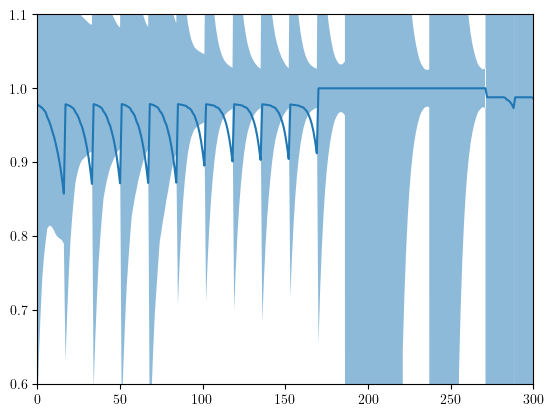

In [33]:
# sigma_measure/Cl_all_nfw
# Cl_all_fid/Cl_all_nfw
pl.figure()
pl.plot(Cl_all_fid/Cl_all_nfw)
sigma_measure = np.sqrt(np.diag(cov_forecast))
pl.fill_between(np.arange(len(Cl_all_fid)), 1-sigma_measure/Cl_all_nfw, 1+sigma_measure/Cl_all_nfw, alpha=0.5)
pl.ylim(0.6, 1.1)
pl.xlim(0, 300)



(0.0, 300.0)

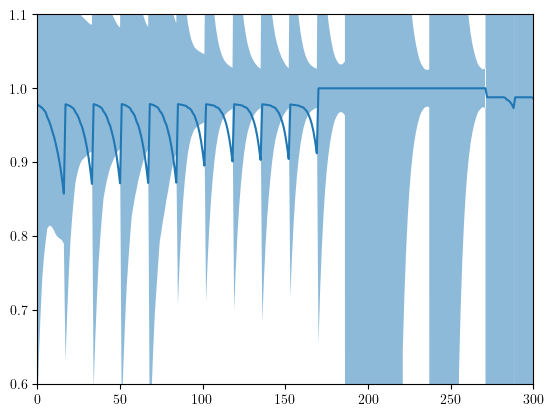

In [34]:
# Cl_all_fid/Cl_all_nfw
pl.figure()
pl.plot(Cl_all_fid/Cl_all_nfw)
sigma_measure = np.sqrt(np.diag(cov_forecast))
pl.fill_between(np.arange(len(Cl_all_fid)), 1-sigma_measure/Cl_all_nfw, 1+sigma_measure/Cl_all_nfw, alpha=0.5)
pl.ylim(0.6, 1.1)
pl.xlim(0, 300)



In [35]:
import jax 
from tqdm import tqdm
import copy


if do_cosmo:



    cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
    # cosmo_params_vary_names_all = ['Om0','sigma8']    

    cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
    for jp in range(len(cosmo_params_vary_names_all)):
        cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

    dmu_cosmo_all = np.zeros((len(ell_sel_all), len(cosmo_params_vary_names_all)))
    for jp in tqdm(range(len(cosmo_params_vary_names_all))):
        cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
        params_fid = jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]])


        def get_mean_cosmo(p):
            sim_params_dict_vary = copy.deepcopy(sim_params_dict)
            other_params_dict_vary = copy.deepcopy(other_params_dict)

            for jp in range(len(cosmo_params_vary_names)):
                sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = p[jp]
            
            get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

            nell = len(ell_array)
            nk = len(analysis_dict['k_array_survey'])
            Cl_all = jnp.zeros((cov_total.shape[0]))
            for jp1 in range(len(bin_comb_all_wprobe)):
                binwprobe1 = bin_comb_all_wprobe[jp1]
                probe1 = binwprobe1[0]
                bin_comb1 = binwprobe1[1]
                b1, b2 = bin_comb1[0], bin_comb1[1]
                if probe1 == 'ky':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
                if probe1 == 'kk':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gg':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gk':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gy':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

            edge_left_pge = ell_edges_left[-1]
            Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
            Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
            Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

            return Cl_all[ell_sel_all]

        jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
        dmu_cosmo = jac_mean(params_fid)
        dmu_cosmo_all[:, jp] = dmu_cosmo[:,0]
        print(np.all(np.isfinite(dmu_cosmo)))

    P = jnp.linalg.inv(cov_forecast)

    F_cosmo = jnp.matmul(dmu_cosmo_all.T, jnp.matmul(P, dmu_cosmo_all))

if do_sim:
    import jax 
    from tqdm import tqdm




    # sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']
    sims_params_vary_names_all = ['beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']
    # sims_params_vary_names_all = ['beta_fshmr', 'gamma_fshmr']

    sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
    for jp in range(len(sims_params_vary_names_all)):
        sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]

    dmu_sims_all = np.zeros((len(ell_sel_all), len(sims_params_vary_names_all)))
    for jp in tqdm(range(len(sims_params_vary_names_all))):
        sim_param_vary_names = [sims_params_vary_names_all[jp]]
        params_fid = jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]])



        def get_mean_sims(p):
            sim_params_dict_vary = copy.deepcopy(sim_params_dict)
            other_params_dict_vary = copy.deepcopy(other_params_dict)

            for jp in range(len(sim_param_vary_names)):
                sim_params_dict_vary[sim_param_vary_names[jp]] = p[jp]
            get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

            nell = len(ell_array)
            nk = len(analysis_dict['k_array_survey'])
            Cl_all = jnp.zeros((cov_total.shape[0]))
            for jp1 in range(len(bin_comb_all_wprobe)):
                binwprobe1 = bin_comb_all_wprobe[jp1]
                probe1 = binwprobe1[0]
                bin_comb1 = binwprobe1[1]
                b1, b2 = bin_comb1[0], bin_comb1[1]
                if probe1 == 'ky':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
                if probe1 == 'kk':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gg':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gk':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gy':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

            edge_left_pge = ell_edges_left[-1]
            Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
            Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
            Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

            return Cl_all[ell_sel_all]

        jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
        dmu_sim = jac_mean(params_fid)
        dmu_sims_all[:,jp] = dmu_sim[:,0]
        print(np.all(np.isfinite(dmu_sim)))


    P = jnp.linalg.inv(cov_forecast)

    F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))


if do_IA:

    import jax 
    from tqdm import tqdm



    IA_params_vary_names_all = ['A_IA', 'eta_IA']

    IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
    for jp in range(len(IA_params_vary_names_all)):
        IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]

    dmu_IA_all = np.zeros((len(ell_sel_all), len(IA_params_vary_names_all)))
    for jp in tqdm(range(len(IA_params_vary_names_all))):
        IA_param_vary_names = [IA_params_vary_names_all[jp]]
        params_fid = jnp.array([other_params_dict[IA_params_vary_names_all[jp]]])


        def get_mean_IA(p):
            sim_params_dict_vary = copy.deepcopy(sim_params_dict)
            other_params_dict_vary = copy.deepcopy(other_params_dict)

            for jp in range(len(IA_param_vary_names)):
                other_params_dict_vary[IA_param_vary_names[jp]] = p[jp]
            
            get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

            nell = len(ell_array)
            nk = len(analysis_dict['k_array_survey'])
            Cl_all = jnp.zeros((cov_total.shape[0]))
            for jp1 in range(len(bin_comb_all_wprobe)):
                binwprobe1 = bin_comb_all_wprobe[jp1]
                probe1 = binwprobe1[0]
                bin_comb1 = binwprobe1[1]
                b1, b2 = bin_comb1[0], bin_comb1[1]
                if probe1 == 'ky':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
                if probe1 == 'kk':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gg':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gk':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])
                if probe1 == 'gy':
                    Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

            edge_left_pge = ell_edges_left[-1]
            Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
            Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
            Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

            return Cl_all[ell_sel_all]

        jac_mean = jax.jit(jax.jacfwd(get_mean_IA))
        dmu_IA = jac_mean(params_fid)
        dmu_IA_all[:, jp] = dmu_IA[:, 0]

    P = jnp.linalg.inv(cov_forecast)
    F_IA = jnp.matmul(dmu_IA_all.T, jnp.matmul(P, dmu_IA_all))

if do_multz:

    import jax 

    @jax.jit
    def get_mean_mult_shear(p):
        sim_params_dict_vary = copy.deepcopy(sim_params_dict)
        other_params_dict_vary = copy.deepcopy(other_params_dict)

        other_params_dict_vary['mult_shear_bias_array'] = p

        get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

        nell = len(ell_array)
        nk = len(analysis_dict['k_array_survey'])
        Cl_all = jnp.zeros((cov_total.shape[0]))
        for jp1 in range(len(bin_comb_all_wprobe)):
            binwprobe1 = bin_comb_all_wprobe[jp1]
            probe1 = binwprobe1[0]
            bin_comb1 = binwprobe1[1]
            b1, b2 = bin_comb1[0], bin_comb1[1]
            if probe1 == 'ky':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
            if probe1 == 'kk':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
            if probe1 == 'gg':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
            if probe1 == 'gk':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])
            if probe1 == 'gy':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

        edge_left_pge = ell_edges_left[-1]
        Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
        Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
        Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

        return Cl_all[ell_sel_all]

    mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
    params_fid = jnp.zeros(len(mult_shear_vary_names))
    jac_mean = jax.jit(jax.jacfwd(get_mean_mult_shear))
    dmu_mult_shear_all = jac_mean(params_fid)

    P = jnp.linalg.inv(cov_forecast)

    F_mz = jnp.matmul(dmu_mult_shear_all.T, jnp.matmul(P, dmu_mult_shear_all))

    # import numpy as np
    d = np.ones(F_mz.shape[0]) *  1/(3e-3)**2

    F_mz = F_mz + np.diag(d)



if do_dz:

    import jax 

    @jax.jit
    def get_mean_bias_Deltaz(p):
        sim_params_dict_vary = copy.deepcopy(sim_params_dict)
        other_params_dict_vary = copy.deepcopy(other_params_dict)

        other_params_dict_vary['Delta_z_bias_array'] = p

        get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

        nell = len(ell_array)
        nk = len(analysis_dict['k_array_survey'])
        Cl_all = jnp.zeros((cov_total.shape[0]))
        for jp1 in range(len(bin_comb_all_wprobe)):
            binwprobe1 = bin_comb_all_wprobe[jp1]
            probe1 = binwprobe1[0]
            bin_comb1 = binwprobe1[1]
            b1, b2 = bin_comb1[0], bin_comb1[1]
            if probe1 == 'ky':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
            if probe1 == 'kk':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
            if probe1 == 'gg':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
            if probe1 == 'gk':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])
            if probe1 == 'gy':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

        edge_left_pge = ell_edges_left[-1]
        Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
        Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
        Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

        return Cl_all[ell_sel_all]

    Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
    params_fid = jnp.zeros(len(Delta_shear_vary_names))
    jac_mean = jax.jit(jax.jacfwd(get_mean_bias_Deltaz))
    dmu_bias_Deltaz_all = jac_mean(params_fid)


    P = jnp.linalg.inv(cov_forecast)

    F_dz = jnp.matmul(dmu_bias_Deltaz_all.T, jnp.matmul(P, dmu_bias_Deltaz_all))

    # import numpy as np
    d = np.ones(F_dz.shape[0]) *  1/(1e-3)**2

    F_dz = F_dz + np.diag(d)



 20%|██        | 1/5 [01:04<04:17, 64.48s/it]

True


 40%|████      | 2/5 [02:09<03:14, 64.91s/it]

True


 60%|██████    | 3/5 [03:08<02:04, 62.19s/it]

...

 86%|████████▌ | 6/7 [03:58<00:40, 40.18s/it]

True


100%|██████████| 7/7 [04:36<00:00, 39.51s/it]


True


100%|██████████| 2/2 [01:00<00:00, 30.44s/it]


In [36]:

dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all, dmu_IA_all, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
param_vary_name_all = cosmo_params_vary_names_all + sims_params_vary_names_all + IA_params_vary_names_all + mult_shear_vary_names + Delta_shear_vary_names
P = jnp.linalg.inv(cov_forecast)

F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))

import numpy as np
d = np.zeros(F_all.shape[0])
nbins = analysis_dict['nz_source_info_dict']['nbins']
d[F_all.shape[0]-nbins:] = 1/(1e-3)**2
d[F_all.shape[0]-2*nbins:F_all.shape[0]-nbins] = 1/(3e-3)**2

F_all = F_all + np.diag(d)
cov_params = np.linalg.inv(F_all)
sigma_params = np.sqrt(np.diag(cov_params))

shift = jnp.matmul(dmu_all.T, jnp.matmul(P, Delta_Cl_all[:, None]))
delta_params = np.matmul(np.linalg.inv(F_all), shift)

saved_dict_final_F = {}
saved_dict_final_F['F_all'] = F_all
saved_dict_final_F['F_cosmo'] = F_cosmo
saved_dict_final_F['F_sims'] = F_sims
saved_dict_final_F['F_IA'] = F_IA
saved_dict_final_F['F_mz'] = F_mz
saved_dict_final_F['F_dz'] = F_dz

saved_dict_final_F['dmu_cosmo_all'] = dmu_cosmo_all
saved_dict_final_F['dmu_sims_all'] = dmu_sims_all
saved_dict_final_F['dmu_IA_all'] = dmu_IA_all
saved_dict_final_F['dmu_mult_shear_all'] = dmu_mult_shear_all
saved_dict_final_F['dmu_bias_Deltaz_all'] = dmu_bias_Deltaz_all
saved_dict_final_F['dmu_all'] = dmu_all

saved_dict_final_F['Cl_all_nfw'] = Cl_all_nfw
saved_dict_final_F['Cl_all_fid'] = Cl_all_fid
saved_dict_final_F['delta_Cl_all'] = Delta_Cl_all


saved_dict_final_F['delta_params'] = delta_params
saved_dict_final_F['sigma_params'] = sigma_params
saved_dict_final_F['bias_sigma_params'] = np.abs(delta_params)/sigma_params


saved_dict_final_F['param_vary_name_all'] = param_vary_name_all
saved_dict_final_F['cosmo_params_vary_names_all'] = cosmo_params_vary_names_all
saved_dict_final_F['sims_params_vary_names_all'] = sims_params_vary_names_all
saved_dict_final_F['IA_params_vary_names_all'] = IA_params_vary_names_all
saved_dict_final_F['mult_shear_vary_names'] = mult_shear_vary_names
saved_dict_final_F['Delta_shear_vary_names'] = Delta_shear_vary_names

saved_dict_final_F['sim_params_dict'] = sim_params_dict
saved_dict_final_F['halo_params_dict'] = halo_params_dict
saved_dict_final_F['analysis_dict'] = analysis_dict
saved_dict_final_F['other_params_dict'] = other_params_dict

# save_fname = abs_path_data + f'/pge/Fisher_final_probes_{probes_forecast_all_str}_ellmax_{sc_val}.pk'


In [37]:
# np.abs(delta_params)[:,0]/sigma_params
# F_all


In [38]:
param_labels_dict = {
    'Om0': r'$\Omega_{\rm m}$',
    'Ob0': r'$\Omega_{\rm b}$',
    'H0': r'$H_0$',
    'ns': r'$n_{\rm s}$',
    'sigma8': r'$\sigma_8$',
    'theta_ej_0': r'$\theta_{\rm ej, 0}$',
    'mu_beta': r'$\mu_\beta$',
    'delta_rhogas': r'$\delta_{\rho_{\rm gas}}$',
    'gamma_rhogas': r'$\gamma_{\rho_{\rm gas}}$',
    'alpha_nt': r'$\alpha_{\rm nt}$',
    'beta_fshmr': r'$\beta_{\rm fshmr}$',
    'gamma_fshmr': r'$\gamma_{\rm fshmr}$',
    'Bcut_Nsat': r'$B_{\rm cut}^{\rm N_{sat}}$',
    'betacut_Nsat': r'$\beta_{\rm cut}^{\rm N_{sat}}$',
    'betasat_Nsat': r'$\beta_{\rm sat}^{\rm N_{sat}}$',
    'siglogMstar_Ncen': r'$\sigma_{\log M_\star}^{\rm N_{cen}}$',
    'alphasat_Nsat': r'$\alpha_{\rm sat}^{\rm N_{sat}}$',
    'A_IA': r'$A_{\rm IA}$',
    'eta_IA': r'$\eta_{\rm IA}$',
    'mult_shear_bias_bin1': r'$m_1$',
    'mult_shear_bias_bin2': r'$m_2$',
    'mult_shear_bias_bin3': r'$m_3$',
    'mult_shear_bias_bin4': r'$m_4$',
    'mult_shear_bias_bin5': r'$m_5$',
    'Delta_z_bias_bin1': r'$\Delta z_1$',
    'Delta_z_bias_bin2': r'$\Delta z_2$',
    'Delta_z_bias_bin3': r'$\Delta z_3$',
    'Delta_z_bias_bin4': r'$\Delta z_4$',
    'Delta_z_bias_bin5': r'$\Delta z_5$'
}


# cosmo_params_vary_names_all = df['cosmo_params_vary_names_all']

cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
for jp in range(len(cosmo_params_vary_names_all)):
    cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]


# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']
# sims_params_vary_names_all = df['sims_params_vary_names_all']


sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
for jp in range(len(sims_params_vary_names_all)):
    sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]


# IA_params_vary_names_all = ['A_IA', 'eta_IA']
# IA_params_vary_names_all = df['IA_params_vary_names_all']

IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
for jp in range(len(IA_params_vary_names_all)):
    IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]


# mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
# mult_shear_vary_names = df['mult_shear_vary_names']
mz_params_fid_all = np.zeros(len(mult_shear_vary_names))

# Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
# Delta_shear_vary_names = df['Delta_shear_vary_names']
dz_params_fid_all = np.zeros(len(mult_shear_vary_names))

param_names_all = np.concatenate([cosmo_params_vary_names_all, sims_params_vary_names_all, IA_params_vary_names_all, mult_shear_vary_names, Delta_shear_vary_names])
param_labels_all = []
for pname in param_names_all:
    param_labels_all.append(param_labels_dict[pname])

fid_params_all = np.concatenate([cosmo_params_fid_all, sims_params_fid_all, IA_params_fid_all, mz_params_fid_all, dz_params_fid_all])


In [39]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import dill
import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = True
%load_ext autoreload
%autoreload 2
import pathlib
import numpy as np
import getdist
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}
cov = np.linalg.inv(F_all)
mean = fid_params_all
# get samples from this multi dimensional gaussian
samples = np.random.multivariate_normal(mean, cov, 100000)
S8 = samples[:,4]*(samples[:,0]/0.3)**0.5
samples_ws8 = np.column_stack((samples, S8))
param_names_all_ws8 = np.concatenate([param_names_all, ['S8']])
param_labels_all_ws8 = np.concatenate([param_labels_all, [r'$S_8$']])

chain1 = MCSamples(samples=samples_ws8, names=param_names_all_ws8,
                        labels=param_labels_all_ws8, name_tag='chain1',settings=settings)


Removed no burn in


/tmp/ipykernel_1232887/113482105.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov, 100000)


In [41]:
# delta_params
# fid_params_all

In [42]:
settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}
cov = np.linalg.inv(F_all)
mean = fid_params_all - delta_params[:,0]
# get samples from this multi dimensional gaussian
samples = np.random.multivariate_normal(mean, cov, 100000)
S8 = samples[:,4]*(samples[:,0]/0.3)**0.5
samples_ws8 = np.column_stack((samples, S8))
param_names_all_ws8 = np.concatenate([param_names_all, ['S8']])
param_labels_all_ws8 = np.concatenate([param_labels_all, [r'$S_8$']])
chain2 = MCSamples(samples=samples_ws8, names=param_names_all_ws8,
                        labels=param_labels_all_ws8, name_tag='chain1',settings=settings)


Removed no burn in


/tmp/ipykernel_1232887/2968711994.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov, 100000)


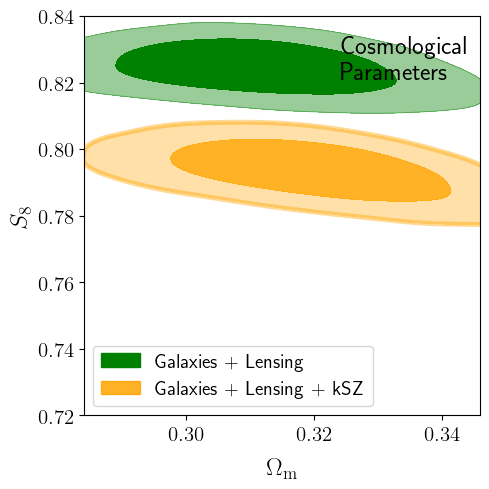

In [43]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain1, chain2]
g.plot_2d(all_samples,'Om0', 'S8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] ,lims=[0.284, 0.346, 0.72, 0.84])  
g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
# g.export(fname = 'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')



In [44]:
sig_S8 = np.sqrt(chain1.cov(pars=['S8']))
mean_S8_1 = chain1.samples[:,-1].mean()
mean_S8_2 = chain2.samples[:,-1].mean()
delta_S8 = mean_S8_2 - mean_S8_1
print(np.abs(delta_S8/sig_S8))



[[5.59064152]]


In [18]:
# import scipy.optimize as op
# import scipy.special as spsp

# def get_max_2dpost(g, root, param1='cosmological_parameters--omega_m', param2='cosmological_parameters--s8',param_pair = None):
#     param_pair = g.get_param_array(root, param_pair or [param1, param2])
    
#     density = g.sample_analyser.get_density_grid(root, param_pair[0], param_pair[1],
#                                                                 conts=g.settings.num_plot_contours,
#                                                                 likes=g.settings.shade_meanlikes)
#     xyind = np.where(density.P == np.amax(density.P))
#     return density.y[xyind[0][0]],density.x[xyind[1][0]]
    
# def get_contour_line(sigma_contour,g, density):

#     contours = spsp.erf(sigma_contour/np.sqrt(2))
#     density.contours = density.getContourLevels([contours])
#     contour_levels = density.contours
#     fig1, ax1 = pl.subplots(1)
#     cs = pl.contour(density.x, density.y, density.P, sorted(contour_levels))
#     lines = []
#     for line in cs.collections[0].get_paths():
#         lines.append(line.vertices)
#     pl.close()
#     return lines

# def get_dmin(line, xref, yref):
#     linex = line[0][:,0]
#     liney = line[0][:,1]
#     d_all = np.sqrt((linex - xref)**2 + (liney - yref)**2)
#     dmin = np.amin(d_all)
#     return dmin

# def lefthand(sigma_contour, g, density, xref, yref): 
#     line = get_contour_line(sigma_contour,g, density)
#     result = get_dmin(line, xref, yref)  
#     return result

# lefthand = np.vectorize(lefthand)
   
# def diff(sigma_contour, g, density, xref, yref):
#     result = lefthand(sigma_contour, g, density, xref, yref)
#     return result

# def root_find(init_x,g, density, xref, yref): 
#     nll = lambda *args: diff(*args)
#     args = (g, density, xref, yref)
#     result = op.root(nll,np.array([init_x]),args=args,options={'maxfev':50})
#     return result

# def min_find(init_x,g, density, xref, yref): 
#     nll = lambda *args: diff(*args)
#     args = (g, density, xref, yref)
#     result = op.fmin(nll,np.array([init_x]),args=args)
#     return result
 
# def unit_vector(vector):
#     return vector / np.linalg.norm(vector)

# def angle_between(v1, v2):
#     v1_u = unit_vector(v1)
#     v2_u = unit_vector(v2)
#     return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))   

# def get_frac_angle(start_coord, end_coord,xlims, ylims):
#     xmean12 = (0.5*(start_coord[0] + end_coord[0]))
#     ymean12 = (0.5*(start_coord[1] + end_coord[1]))
#     dx = xlims[1] - xlims[0]
#     dy = ylims[1] - ylims[0]
#     dxp = xmean12 - end_coord[0]
#     dyp = ymean12 - end_coord[1]
#     angle_deg = 180.+ np.arctan2((end_coord[1]-start_coord[1])/dy,( end_coord[0]-start_coord[0])/dx)*(180./np.pi)
#     return xmean12-dxp/2, ymean12+dyp/3, angle_deg



In [19]:
from getdist.paramnames import escapeLatex, makeList, mergeRenames
roots = makeList([chain1, chain2])
g = plots.getSinglePlotter()

param1 = 'Om0'
param2 = 'S8'
xlabels=[r'$\Omega_m$',r'$S_8$']
xlims = [0.27,0.35]
ylims = [0.72,0.84]

dx = np.absolute(xlims[1] - xlims[0])
dy = np.absolute(ylims[1] - ylims[0])
param2_cont, param1_cont = get_max_2dpost(g, roots[1],param1=param1, param2=param2)
param2_base, param1_base = get_max_2dpost(g, roots[0],param1=param1, param2=param2)
# param1_truth, param2_truth = marker_dict[param1], marker_dict[param2]
print(param1_base, param1_cont)
print(param2_base, param2_cont)

param_pair = g.get_param_array(roots[0], None or [param1, param2])

density = g.sample_analyser.get_density_grid(roots[0], param_pair[0], param_pair[1],
                                                            conts=g.settings.num_plot_contours,
                                                            likes=g.settings.shade_meanlikes)

g = plots.getSinglePlotter()
density_cont = g.sample_analyser.get_density_grid(roots[1], param_pair[0], param_pair[1],
                                                            conts=g.settings.num_plot_contours,
                                                            likes=g.settings.shade_meanlikes)


# # Get the 2D distance in terms of sigma. In case you get some weird getdist error, change the starting guess value (here 0.01)
# res_truth_base = min_find(0.01,g, density, param1_truth, param2_truth)
# print(res_truth_base)
res_cont_base = min_find(0.01,g, density_cont, param1_base, param2_base)
print(res_cont_base)
res_base_cont = min_find(0.01,g, density, param1_cont, param2_cont)
print(res_base_cont)



0.3113139512952045 0.31881020094898616
0.82506738632089 0.7849933262982599


/tmp/ipykernel_1232887/4093031393.py:21: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for line in cs.collections[0].get_paths():


Optimization terminated successfully.
         Current function value: 0.025888
         Iterations: 31
         Function evaluations: 77
[12.2975]
Optimization terminated successfully.
         Current function value: 0.025428
         Iterations: 31
         Function evaluations: 77
[12.2975]


<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

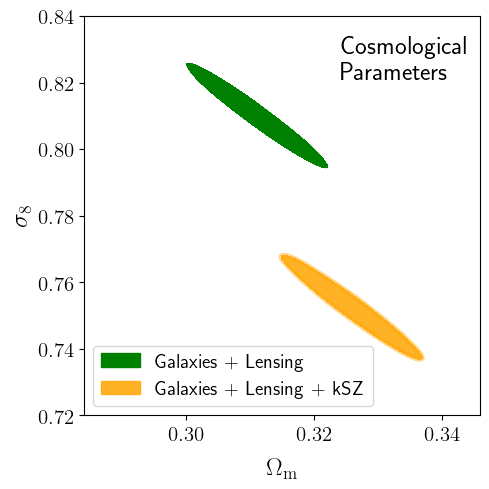

In [33]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain1, chain2]
g.plot_2d(all_samples,'Om0', 'sigma8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] ,lims=[0.284, 0.346, 0.72, 0.84])  
g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
# g.export(fname = 'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')



In [11]:
# delta_params
Delta_Cl_all/np.sqrt(np.diag(cov_forecast))


IndexError: Too many indices for array: 2 non-None/Ellipsis indices for dim 1.

In [12]:
sigma_params


array([0.00182632, 0.00323279, 0.02914631, 0.00816915, 0.12173842,
       0.12682446, 0.00298433, 0.00270886, 0.00246707, 0.00257604,
       0.00257743, 0.00095266, 0.00089438, 0.00094347, 0.00098151,
       0.00099908])

In [15]:
np.abs(delta_params[:,0])


array([1.58535820e-04, 1.06157336e-03, 3.61364392e+00, 2.21866099e+00,
       4.99923150e-02, 6.93880585e-02, 3.49789892e-05, 2.46566919e-04,
       1.36674661e-04, 5.56360250e-05, 2.70409399e-04, 2.92559855e-05,
       7.40430039e-05, 2.67567398e-06, 2.15612258e-05, 1.24915569e-05])

In [16]:
Cl_all_fid/Cl_all_nfw


Array([1.01081959, 1.01329603, 1.01638699, 1.02013969, 1.02508234,
       1.03015459, 1.03321279, 1.04521849, 1.05300971, 1.06054455,
       1.07039776, 1.08036505, 1.09315152, 1.10890082, 1.12808175,
       1.1507546 , 1.17488127, 1.19800375, 1.21720016, 1.22890017,
       1.23082139, 1.22183122, 1.20242708, 1.00792928, 1.00943245,
       1.01139929, 1.01388085, 1.01706185, 1.02017459, 1.02173526,
       1.03128204, 1.0374146 , 1.04413227, 1.0548701 , 1.06619541,
       1.08072043, 1.09822679, 1.11921738, 1.14348054, 1.16905908,
       1.19377258, 1.21496778, 1.22934794, 1.23443251, 1.22873966,
       1.21194452, 1.00751166, 1.00889385, 1.01072554, 1.01306073,
       1.0160587 , 1.01895987, 1.02034425, 1.02972876, 1.03583424,
       1.04264553, 1.05371888, 1.06558229, 1.08059822, 1.09844235,
       1.119831  , 1.14444492, 1.17037754, 1.19549135, 1.21717002,
       1.232103  , 1.23766946, 1.23219141, 1.21509442, 1.007288  ,
       1.00860537, 1.01036327, 1.01261707, 1.01551349, 1.01829

In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import dill
import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = True
%load_ext autoreload
%autoreload 2
import pathlib
import numpy as np
import getdist
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND
%matplotlib inline





In [5]:
ldir = '/mnt/home/spandey/ceph/GODMAX/results/pge/fisher_biases/'

ell_max_all = [500, 1000, 2000, 4000, 8000]
FoM_all_probes_all = []
chain_all_probes_all = []
for ell_max in ell_max_all:
    # FoM_Om_sig8, chain = get_FoM(ldir + 'Fisher_final_pro
    df = dill.load(open(ldir + f'Fisher_biases_Om_S8_probes_kk_kg_gg_ellmax_{ell_max}.pk','rb'))
    # print(df.keys())
    print(df['res_c2_c1'])
    # FoM_Om_sig8, chain = get_FoM(ldir + f'Fisher_biases_Om_S8_probes_kk_kg_gg_ellmax_{ell_max}.pk', chain_label='All probes, lmax='+str(ell_max))
    # FoM_all_probes_all.append(FoM_Om_sig8)



[6.93375]
[12.2975]
[12.2975]
[12.2975]
[12.2975]
